**Name: Rishi Phadale**  
**Roll No.: 23102C0070**  

# Assignment 2.2: Advanced Missing Data Handling
**Topic:** NA, NULL, NaN, Missing-Value Detection and Imputation

**Dataset:** UCI Adult / Census Income Dataset

## 0. Setup: install/load required packages

In [1]:
packages_needed <- c("naniar", "skimr", "dplyr", "ggplot2")
to_install <- packages_needed[!(packages_needed %in% installed.packages()[, "Package"])]
if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cloud.r-project.org")
}

library(naniar)
library(skimr)
library(dplyr)
library(ggplot2)

set.seed(42)  # reproducibility

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’



Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## 1. Load the UCI Adult dataset

We attempt to download the real Adult dataset from the UCI repository. If the
download fails (e.g., no internet access in the sandbox), we fall back to a
synthetically generated dataset with the same column structure, so the rest of
the notebook always runs end-to-end.

In [2]:
col_names <- c("age", "workclass", "fnlwgt", "education", "education_num",
               "marital_status", "occupation", "relationship", "race", "sex",
               "capital_gain", "capital_loss", "hours_per_week",
               "native_country", "income")

load_uci_adult_data <- function() {
  url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
  df <- read.csv(url, header = FALSE, strip.white = TRUE,
                  na.strings = c("?", "NA"), col.names = col_names,
                  stringsAsFactors = FALSE)
  df
}

simulate_adult_data <- function(n = 2000) {
  data.frame(
    age            = round(rnorm(n, 38, 13)),
    workclass      = sample(c("Private", "Self-emp-not-inc", "Local-gov",
                               "State-gov", "Federal-gov", "Self-emp-inc"), n, replace = TRUE),
    fnlwgt         = round(rnorm(n, 189778, 105550)),
    education      = sample(c("Bachelors", "HS-grad", "11th", "Masters",
                               "Some-college", "Doctorate"), n, replace = TRUE),
    education_num  = sample(1:16, n, replace = TRUE),
    marital_status = sample(c("Married-civ-spouse", "Never-married", "Divorced",
                               "Widowed", "Separated"), n, replace = TRUE),
    occupation     = sample(c("Tech-support", "Craft-repair", "Sales",
                               "Exec-managerial", "Prof-specialty", "Other-service"), n, replace = TRUE),
    relationship   = sample(c("Wife", "Own-child", "Husband", "Not-in-family",
                               "Other-relative", "Unmarried"), n, replace = TRUE),
    race           = sample(c("White", "Black", "Asian-Pac-Islander",
                               "Amer-Indian-Eskimo", "Other"), n, replace = TRUE),
    sex            = sample(c("Male", "Female"), n, replace = TRUE),
    capital_gain   = round(abs(rnorm(n, 1077, 7385))),
    capital_loss   = round(abs(rnorm(n, 87, 403))),
    hours_per_week = round(rnorm(n, 40, 12)),
    native_country = sample(c("United-States", "Mexico", "Philippines", "Germany",
                               "India", "Canada"), n, replace = TRUE),
    income         = sample(c("<=50K", ">50K"), n, replace = TRUE),
    stringsAsFactors = FALSE
  )
}

adult_data <- tryCatch({
  df <- load_uci_adult_data()
  message("Loaded real UCI Adult dataset (", nrow(df), " rows).")
  df
}, error = function(e) {
  message("Could not download UCI Adult dataset (", conditionMessage(e), "). Using simulated dataset instead.")
  simulate_adult_data()
})

# For speed/readability in this lab, work with a manageable sample
if (nrow(adult_data) > 3000) {
  adult_data <- adult_data[sample(nrow(adult_data), 3000), ]
  rownames(adult_data) <- NULL
}

str(adult_data)
head(adult_data)

Loaded real UCI Adult dataset (32561 rows).



'data.frame':	3000 obs. of  15 variables:
 $ age           : int  23 23 29 37 19 48 39 47 41 38 ...
 $ workclass     : chr  "Private" "Private" "Private" "Private" ...
 $ fnlwgt        : int  203139 373628 242597 301070 145844 397466 225605 172034 397280 223004 ...
 $ education     : chr  "Some-college" "Bachelors" "Bachelors" "HS-grad" ...
 $ education_num : int  10 13 13 9 12 10 9 9 13 10 ...
 $ marital_status: chr  "Never-married" "Never-married" "Never-married" "Divorced" ...
 $ occupation    : chr  "Other-service" "Other-service" "Tech-support" "Farming-fishing" ...
 $ relationship  : chr  "Other-relative" "Own-child" "Not-in-family" "Unmarried" ...
 $ race          : chr  "White" "White" "White" "White" ...
 $ sex           : chr  "Female" "Female" "Male" "Male" ...
 $ capital_gain  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ capital_loss  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hours_per_week: int  40 20 40 45 50 60 24 75 72 75 ...
 $ native_country: chr  "United-States" "United-States" "United

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,23,Private,203139,Some-college,10,Never-married,Other-service,Other-relative,White,Female,0,0,40,United-States,<=50K
2,23,Private,373628,Bachelors,13,Never-married,Other-service,Own-child,White,Female,0,0,20,United-States,<=50K
3,29,Private,242597,Bachelors,13,Never-married,Tech-support,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,37,Private,301070,HS-grad,9,Divorced,Farming-fishing,Unmarried,White,Male,0,0,45,United-States,<=50K
5,19,Private,145844,Assoc-acdm,12,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,50,United-States,<=50K
6,48,Self-emp-not-inc,397466,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,<=50K


## 2. Simulate different missing-data scenarios

We deliberately introduce:
- `NA` values in `hours_per_week`
- Blank strings `""` in `workclass` (a categorical variable)
- `NaN` values in `capital_gain`
- Impossible values `age = 999` in `age`

In [3]:
n <- nrow(adult_data)
adult_data$age            <- as.numeric(adult_data$age)
adult_data$hours_per_week <- as.numeric(adult_data$hours_per_week)
adult_data$capital_gain   <- as.numeric(adult_data$capital_gain)
adult_data$workclass      <- as.character(adult_data$workclass)

idx_all      <- sample(seq_len(n), size = min(40, n))
idx_na_hours <- idx_all[1:10]
idx_blank_wc <- idx_all[11:20]
idx_nan_cg   <- idx_all[21:30]
idx_age999   <- idx_all[31:40]

adult_data$hours_per_week[idx_na_hours] <- NA           # NA
adult_data$workclass[idx_blank_wc]      <- ""            # blank string
adult_data$capital_gain[idx_nan_cg]     <- NaN            # NaN
adult_data$age[idx_age999]              <- 999             # impossible value

cat("Injected problems:\n")
cat(" - NA in hours_per_week at rows:", idx_na_hours, "\n")
cat(" - Blank strings in workclass at rows:", idx_blank_wc, "\n")
cat(" - NaN in capital_gain at rows:", idx_nan_cg, "\n")
cat(" - Impossible age = 999 at rows:", idx_age999, "\n")

Injected problems:
 - NA in hours_per_week at rows: 2297 1683 266 528 575 465 1816 1372 58 708 
 - Blank strings in workclass at rows: 1098 521 717 371 2044 776 690 2896 1721 464 
 - NaN in capital_gain at rows: 621 1316 158 1365 927 2826 1420 1892 59 2923 
 - Impossible age = 999 at rows: 1564 767 2357 2166 2001 294 1023 1663 833 2271 


## Task 1: Identify different forms of missing or invalid data

In [4]:
# --- (a) NA detection ---
cat("Number of NA in hours_per_week:", sum(is.na(adult_data$hours_per_week)), "\n")

# --- (b) NaN detection ---
cat("Number of NaN in capital_gain:", sum(is.nan(adult_data$capital_gain)), "\n")
cat("Number of NA in capital_gain (includes NaN):", sum(is.na(adult_data$capital_gain)), "\n")

Number of NA in hours_per_week: 10 
Number of NaN in capital_gain: 10 
Number of NA in capital_gain (includes NaN): 10 


In [5]:
# --- (c) is.null() demonstrated on an R object, and why it behaves
#          differently inside a data frame ---

some_object <- NULL
cat("is.null(some_object):", is.null(some_object), "\n")

another_object <- 5
cat("is.null(another_object):", is.null(another_object), "\n\n")

# What happens if we try to put NULL into a single cell of a data-frame column?
demo_vec <- c(1, 2, 3)
cat("Before: demo_vec =", demo_vec, "(length", length(demo_vec), ")\n")

result <- tryCatch({
  demo_vec[2] <- NULL   # this is not valid for atomic vectors
  demo_vec
}, error = function(e) {
  message("Assigning NULL into a vector element raised an error: ", conditionMessage(e))
  NA
})

# Contrast with a list, where NULL assignment IS allowed and removes the element
demo_list <- list(1, 2, 3)
cat("\nBefore: demo_list has", length(demo_list), "elements\n")
demo_list[[2]] <- NULL
cat("After demo_list[[2]] <- NULL: demo_list has", length(demo_list), "elements (element removed, not replaced!)\n\n")

cat("Conclusion: NULL represents the absence of an object. Inside an atomic\n",
    "vector/data-frame column it cannot exist as a 'value' the way NA can --\n",
    "attempting to insert it either errors out or removes/shrinks the structure.\n",
    "NA, by contrast, is a proper placeholder that keeps vector length and type\n",
    "intact. This is why blank strings ('') are NOT the same thing as NULL.\n", sep = "")

is.null(some_object): TRUE 
is.null(another_object): FALSE 

Before: demo_vec = 1 2 3 (length 3 )


Assigning NULL into a vector element raised an error: replacement has length zero




Before: demo_list has 3 elements
After demo_list[[2]] <- NULL: demo_list has 2 elements (element removed, not replaced!)

Conclusion: NULL represents the absence of an object. Inside an atomic
vector/data-frame column it cannot exist as a 'value' the way NA can --
attempting to insert it either errors out or removes/shrinks the structure.
NA, by contrast, is a proper placeholder that keeps vector length and type
intact. This is why blank strings ('') are NOT the same thing as NULL.


In [6]:
# --- (d) Blank string detection ---
n_blank_workclass <- sum(adult_data$workclass == "", na.rm = TRUE)
cat("Number of blank strings in workclass:", n_blank_workclass, "\n")

# --- (e) Impossible value detection ---
n_impossible_age <- sum(adult_data$age == 999, na.rm = TRUE)
cat("Number of impossible age values (age == 999):", n_impossible_age, "\n")

Number of blank strings in workclass: 10 
Number of impossible age values (age == 999): 10 


In [7]:
# --- (f) Variable-wise missing-value summary using naniar ---
# Note: at this point, blanks ("") and 999 are NOT yet real NAs to R,
# so miss_var_summary() only reports the true NA/NaN cases so far.
miss_var_summary(adult_data)

variable,n_miss,pct_miss
<chr>,<int>,<num>
occupation,168,5.6
workclass,167,5.57
native_country,49,1.63
capital_gain,10,0.333
hours_per_week,10,0.333
age,0,0
fnlwgt,0,0
education,0,0
education_num,0,0


## Task 2: Missing-data treatment strategy

Steps:
1. Convert impossible numeric values (`age == 999`) to `NA`.
2. Replace blank categorical values (`""`) with `"Unknown"`.
3. Impute missing numeric values (e.g., `hours_per_week`) using the median.
4. Remove observations with unrecoverable `NaN` values (`capital_gain`) where
   appropriate.
5. Use `complete.cases()` to identify complete vs incomplete observations.

In [8]:
adult_clean <- adult_data

# 1. Impossible numeric values -> NA
adult_clean$age[adult_clean$age == 999] <- NA
cat("Impossible age values converted to NA. Remaining age==999 count:",
    sum(adult_clean$age == 999, na.rm = TRUE), "\n")

# 2. Blank categorical values -> "Unknown"
adult_clean$workclass[adult_clean$workclass == ""] <- "Unknown"
cat("Blank workclass values replaced. Remaining blanks:",
    sum(adult_clean$workclass == "", na.rm = TRUE), "\n")

# 3. Impute missing numeric values with the median (hours_per_week, and the
#    now-NA age values) -- uses the custom function defined in Task 3 below,
#    defined first here so it's available for this step.
impute_median <- function(x) {
  if (!is.numeric(x)) {
    stop("impute_median() expects a numeric vector.")
  }
  missing_idx <- is.na(x)
  n_missing <- sum(missing_idx)
  if (n_missing > 0) {
    med <- median(x, na.rm = TRUE)
    x[missing_idx] <- med
    message("impute_median(): replaced ", n_missing, " missing value(s) with median = ", med)
  } else {
    message("impute_median(): no missing values found; vector returned unchanged.")
  }
  x
}

adult_clean$hours_per_week <- impute_median(adult_clean$hours_per_week)
adult_clean$age            <- impute_median(adult_clean$age)

# 4. Remove observations with unrecoverable NaN values (capital_gain)
n_before_nan_removal <- nrow(adult_clean)
adult_clean <- adult_clean[!is.nan(adult_clean$capital_gain), ]
cat("Rows removed due to unrecoverable NaN in capital_gain:",
    n_before_nan_removal - nrow(adult_clean), "\n")

# 5. complete.cases() to flag complete vs incomplete observations (on the
#    ORIGINAL uncleaned data, for comparison)
complete_flags <- complete.cases(adult_data)
cat("\nOriginal data -- complete cases:", sum(complete_flags),
    "| incomplete cases:", sum(!complete_flags), "\n")

Impossible age values converted to NA. Remaining age==999 count: 0 
Blank workclass values replaced. Remaining blanks: 0 


impute_median(): replaced 10 missing value(s) with median = 40

impute_median(): replaced 10 missing value(s) with median = 37



Rows removed due to unrecoverable NaN in capital_gain: 10 

Original data -- complete cases: 2768 | incomplete cases: 232 


## Task 3: Custom median-imputation function (standalone demonstration)

The function was defined above so it could be used directly in the Task 2
pipeline. Here it is shown again on its own with a clear step-by-step
structure, plus a small worked example.

In [9]:
impute_median <- function(x) {
  # 1. Validate input
  if (!is.numeric(x)) {
    stop("impute_median() expects a numeric vector.")
  }

  # 2. Identify missing values
  missing_idx <- is.na(x)

  # 3. Calculate the median of the valid (non-missing) observations
  med <- median(x, na.rm = TRUE)

  # 4. Replace missing observations with the median
  x[missing_idx] <- med

  # 5. Return the cleaned vector
  x
}

# Worked example
example_vec <- c(25, 30, NA, 40, NA, 35, 200)
cat("Original vector: ", example_vec, "\n")
cat("Median (na.rm=TRUE):", median(example_vec, na.rm = TRUE), "\n")
cat("Imputed vector:  ", impute_median(example_vec), "\n")

Original vector:  25 30 NA 40 NA 35 200 
Median (na.rm=TRUE): 35 
Imputed vector:   25 30 35 40 35 35 200 


## Task 4: Missingness before vs after cleaning

In [10]:
# --- Before cleaning: number and percentage missing per variable ---
cat("---- BEFORE cleaning ----\n")
before_summary <- miss_var_summary(adult_data)
print(before_summary)

cat("\nTotal missing cells (NA/NaN only, before treating blanks/999):",
    sum(is.na(adult_data)), "out of", prod(dim(adult_data)),
    sprintf("(%.2f%%)\n", 100 * sum(is.na(adult_data)) / prod(dim(adult_data))))

---- BEFORE cleaning ----
# A tibble: 15 × 3
   variable       n_miss pct_miss
   <chr>           <int>    <num>
 1 occupation        168    5.6  
 2 workclass         167    5.57 
 3 native_country     49    1.63 
 4 capital_gain       10    0.333
 5 hours_per_week     10    0.333
 6 age                 0    0    
 7 fnlwgt              0    0    
 8 education           0    0    
 9 education_num       0    0    
10 marital_status      0    0    
11 relationship        0    0    
12 race                0    0    
13 sex                 0    0    
14 capital_loss        0    0    
15 income              0    0    

Total missing cells (NA/NaN only, before treating blanks/999): 404 out of 45000 (0.90%)


In [11]:
# --- After cleaning: number and percentage missing per variable ---
cat("---- AFTER cleaning ----\n")
after_summary <- miss_var_summary(adult_clean)
print(after_summary)

cat("\nTotal missing cells after treatment:",
    sum(is.na(adult_clean)), "out of", prod(dim(adult_clean)),
    sprintf("(%.2f%%)\n", 100 * sum(is.na(adult_clean)) / prod(dim(adult_clean))))

---- AFTER cleaning ----
# A tibble: 15 × 3
   variable       n_miss pct_miss
   <chr>           <int>    <num>
 1 occupation        167     5.59
 2 workclass         166     5.55
 3 native_country     49     1.64
 4 age                 0     0   
 5 fnlwgt              0     0   
 6 education           0     0   
 7 education_num       0     0   
 8 marital_status      0     0   
 9 relationship        0     0   
10 race                0     0   
11 sex                 0     0   
12 capital_gain        0     0   
13 capital_loss        0     0   
14 hours_per_week      0     0   
15 income              0     0   

Total missing cells after treatment: 382 out of 44850 (0.85%)


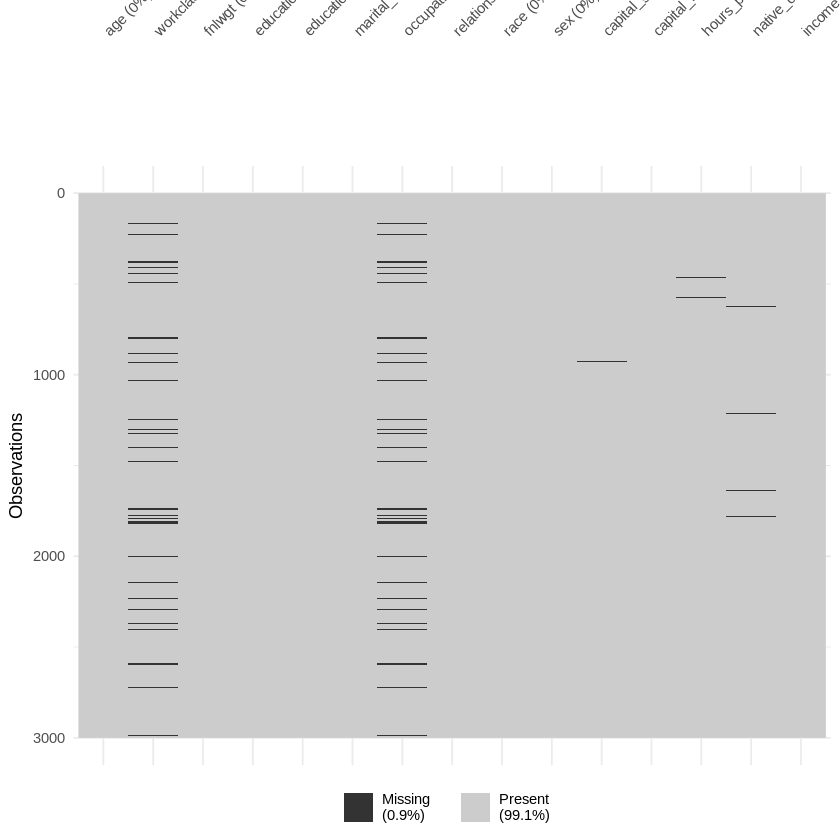

In [18]:
# --- Missingness visualization with naniar ---
vis_miss(adult_data)

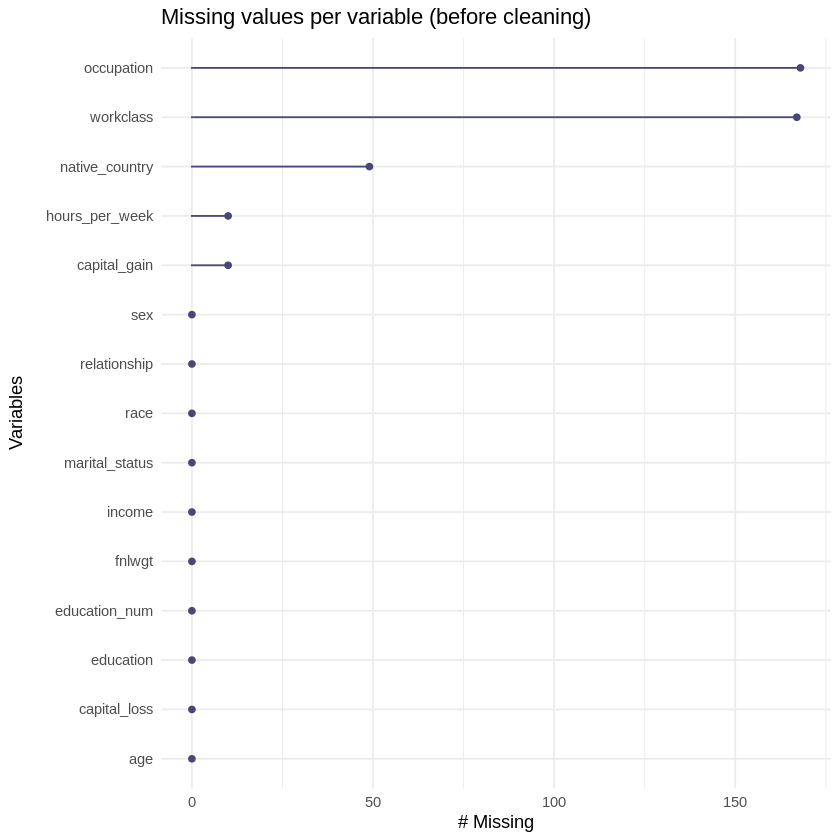

In [13]:
# Variable-wise missingness plot BEFORE cleaning
gg_miss_var(adult_data) + labs(title = "Missing values per variable (before cleaning)")

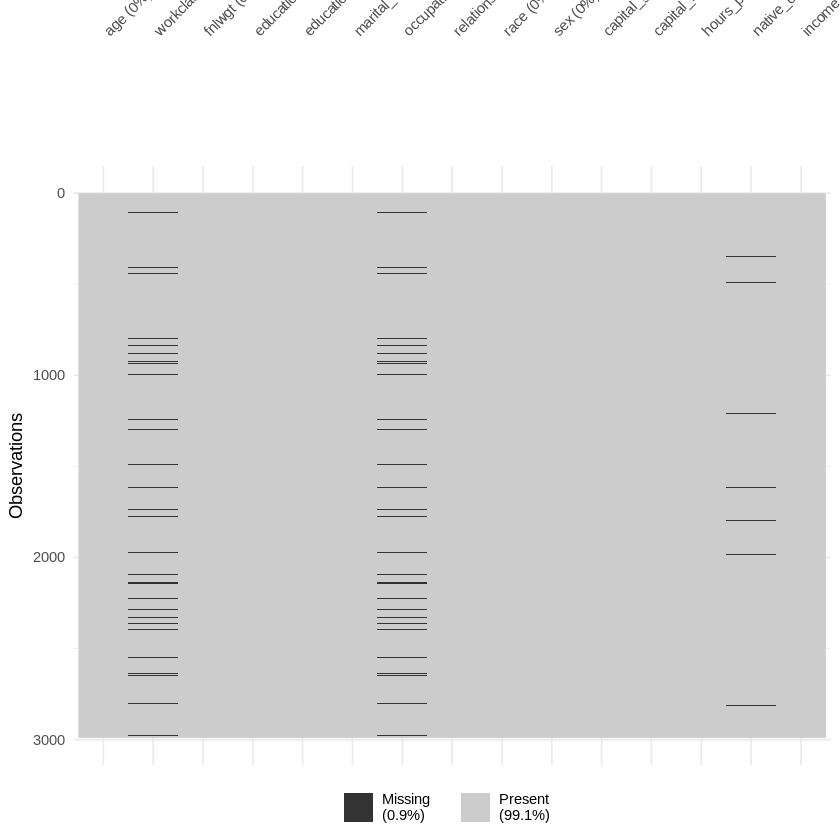

In [14]:
# Overall missingness pattern AFTER cleaning
vis_miss(adult_clean)

## Task 5: Validate the cleaned dataset

In [15]:
# --- Comprehensive summary with skimr ---
skim(adult_clean)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,workclass,166,0.9444816,7,16,0,8,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,education,0,1.0000000,3,12,0,16,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,marital_status,0,1.0000000,7,21,0,7,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,occupation,167,0.9441472,5,17,0,14,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,relationship,0,1.0000000,4,14,0,6,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,race,0,1.0000000,5,18,0,5,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,sex,0,1.0000000,4,6,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,native_country,49,0.9836120,4,18,0,36,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,income,0,1.0000000,4,5,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA


In [16]:
cat("---- Final validation checks ----\n")

cat("1. Impossible age values (== 999) remaining:",
    sum(adult_clean$age == 999, na.rm = TRUE), "\n")

cat("2. Untreated NA in hours_per_week:", sum(is.na(adult_clean$hours_per_week)), "\n")
cat("   Untreated NA in age:", sum(is.na(adult_clean$age)), "\n")
cat("   Untreated NaN in capital_gain:", sum(is.nan(adult_clean$capital_gain)), "\n")

cat("3. Blank strings remaining in workclass:",
    sum(adult_clean$workclass == "", na.rm = TRUE), "\n")

cat("4. Complete cases in cleaned data:", sum(complete.cases(adult_clean)),
    "out of", nrow(adult_clean), "rows\n")

validation_passed <- all(
  sum(adult_clean$age == 999, na.rm = TRUE) == 0,
  sum(is.na(adult_clean$hours_per_week)) == 0,
  sum(is.na(adult_clean$age)) == 0,
  sum(is.nan(adult_clean$capital_gain)) == 0,
  sum(adult_clean$workclass == "", na.rm = TRUE) == 0
)

if (validation_passed) {
  cat("\nVALIDATION PASSED: dataset is clean with respect to the target variables.\n")
} else {
  cat("\nVALIDATION FAILED: please review the treatment steps above.\n")
}

---- Final validation checks ----
1. Impossible age values (== 999) remaining: 0 
2. Untreated NA in hours_per_week: 0 
   Untreated NA in age: 0 
   Untreated NaN in capital_gain: 0 
3. Blank strings remaining in workclass: 0 
4. Complete cases in cleaned data: 2776 out of 2990 rows

VALIDATION PASSED: dataset is clean with respect to the target variables.


## Save the cleaned dataset

In [17]:
output_path <- "cleaned_adult_data.csv"
write.csv(adult_clean, output_path, row.names = FALSE)
cat("Saved cleaned dataset to:", normalizePath(output_path), "\n")

head(adult_clean)

Saved cleaned dataset to: /content/cleaned_adult_data.csv 


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<dbl>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<chr>
1,23,Private,203139,Some-college,10,Never-married,Other-service,Other-relative,White,Female,0,0,40,United-States,<=50K
2,23,Private,373628,Bachelors,13,Never-married,Other-service,Own-child,White,Female,0,0,20,United-States,<=50K
3,29,Private,242597,Bachelors,13,Never-married,Tech-support,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,37,Private,301070,HS-grad,9,Divorced,Farming-fishing,Unmarried,White,Male,0,0,45,United-States,<=50K
5,19,Private,145844,Assoc-acdm,12,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,50,United-States,<=50K
6,48,Self-emp-not-inc,397466,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,<=50K
